# Демо: улучшение спутниковых снимков через Spark + HDFS

Этот ноутбук демонстрирует полный цикл:
1. Генерация синтетического тестового снимка.
2. Запуск распределённой обработки через PySpark.
3. Сохранение исходного и обработанного изображений в HDFS.
4. Визуальное сравнение результатов и метрики качества (PSNR/SSIM).

> Пайплайн использует mock-модель (unsharp-mask + denoise) — см. `config/settings.yaml`, параметр `model.use_mock`.

## 1. Подготовка тестовых данных

In [1]:
import sys, os
sys.path.insert(0, '/app')

from pathlib import Path
import subprocess

sample_path = Path('/app/data/samples/sat_demo.png')
if not sample_path.exists():
    subprocess.run(['python', '/app/scripts/generate_sample.py',
                    '--output', str(sample_path), '--size', '1536'], check=True)
print(f'Тестовый снимок: {sample_path} ({sample_path.stat().st_size // 1024} KB)')

Тестовый снимок: /app/data/samples/sat_demo.png (91580 KB)


/opt/conda/lib/python3.11/site-packages/PIL/Image.py:3182: DecompressionBombWarning: Image size (104286058 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


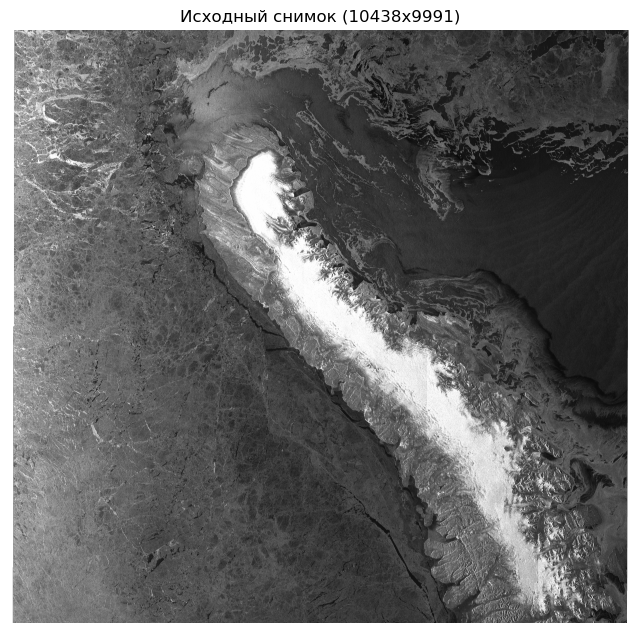

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(sample_path)
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title(f'Исходный снимок ({img.size[0]}x{img.size[1]})')
plt.axis('off')
plt.show()

## 2. Запуск пайплайна через PySpark

Под капотом: валидация → тайлинг (512×512 с overlap 32) → `mapPartitions` по Spark-воркерам → gaussian-сборка → запись в HDFS.

In [3]:
import os
import subprocess

# 🔍 Находим JAVA_HOME динамически, если он не задан
if not os.environ.get('JAVA_HOME'):
    try:
        java_real = subprocess.check_output(
            ['readlink', '-f', '/usr/bin/java'], text=True
        ).strip()
        os.environ['JAVA_HOME'] = java_real.replace('/bin/java', '')
        print(f"🔧 AUTO: JAVA_HOME установлен в {os.environ['JAVA_HOME']}")
    except Exception as e:
        raise RuntimeError(f"Не удалось найти Java: {e}")

# ✅ Теперь safely вызываем hadoop classpath
if 'CLASSPATH' not in os.environ or not os.environ['CLASSPATH']:
    cp = subprocess.check_output(
        ['/opt/hadoop/bin/hadoop', 'classpath', '--glob'],
        text=True,
        env=os.environ  # ← явно передаём окружение с JAVA_HOME
    ).strip()
    os.environ['CLASSPATH'] = cp
    print(f'✅ CLASSPATH настроен ({len(cp)} символов)')

🔧 AUTO: JAVA_HOME установлен в /usr/lib/jvm/java-17-openjdk-amd64
✅ CLASSPATH настроен (19474 символов)


In [4]:
# Убедимся, что CLASSPATH настроен для pyarrow.HadoopFileSystem
import os
if 'CLASSPATH' not in os.environ or not os.environ['CLASSPATH']:
    cp = subprocess.check_output(['/opt/hadoop/bin/hadoop', 'classpath', '--glob']).decode().strip()
    os.environ['CLASSPATH'] = cp
print('CLASSPATH настроен:', bool(os.environ.get('CLASSPATH')))

CLASSPATH настроен: True


In [5]:
from src.main import run_enhancement_pipeline

result = run_enhancement_pipeline(
    image_path=str(sample_path),
    image_id='SAT_DEMO_001',
    config_path='/app/config/settings.yaml',
)
result

2026-04-19 20:59:59,451 | INFO     | src.preprocessing.tiling | Валидация пройдена: sat_demo.png (10438x9991)


/opt/conda/lib/python3.11/site-packages/PIL/Image.py:3182: DecompressionBombWarning: Image size (104286058 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


2026-04-19 21:00:06,024 | INFO     | src.preprocessing.tiling | Изображение загружено: shape=(9991, 10438, 3) dtype=uint8
2026-04-19 21:00:06,299 | INFO     | src.preprocessing.tiling | Сформировано 462 тайлов (grid=21x22, tile=512, overlap=32)
2026-04-19 21:00:06,392 | INFO     | SatlasImageEnhancement | Подготовлено 462 тайлов для Spark
2026-04-19 21:00:09,355 | INFO     | SatlasImageEnhancement | SparkContext готов: SatlasImageEnhancement
2026-04-19 21:00:32,156 | INFO     | SatlasImageEnhancement | 💾 Память ДО инференса: 1010.9 MB
2026-04-19 21:00:34,592 | INFO     | SatlasImageEnhancement | Инференс завершён: 462 тайлов за 2.44 сек (189.67 тайлов/сек)
2026-04-19 21:00:34,594 | INFO     | SatlasImageEnhancement | 💾 Память ПОСЛЕ collect: 1109.8 MB
2026-04-19 21:00:35,581 | INFO     | SatlasImageEnhancement | 💾 Память ПЕРЕД сборкой: 1343.1 MB
2026-04-19 21:00:47,621 | INFO     | src.postprocessing.assembly | Собрано изображение 10438x9991 из 462 тайлов (blending=gaussian)
2026-04-19 

/opt/conda/lib/python3.11/site-packages/PIL/Image.py:3182: DecompressionBombWarning: Image size (104286058 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


2026-04-19 21:01:01,794 | INFO     | SatlasImageEnhancement | 📉 Изображение большое, считаем метрики на даунскейле 2×
2026-04-19 21:01:01,803 | WARNING  | SatlasImageEnhancement | ⚠️ Не удалось рассчитать метрики: No module named 'cv2', пропускаем
2026-04-19 21:01:03,469 | INFO     | src.storage.hdfs_client | Подключение к HDFS: namenode:9000 (pyarrow)
2026-04-19 21:01:04,244 | INFO     | src.storage.hdfs_client | Загружен в HDFS: /app/data/samples/sat_demo.png -> /data/input/2026-04-19/SAT_DEMO_001_original.png
2026-04-19 21:01:25,070 | INFO     | src.storage.hdfs_client | Записано в HDFS: /data/output/2026-04-19/SAT_DEMO_001_enhanced.png (108377917 байт)
2026-04-19 21:01:25,110 | INFO     | src.storage.hdfs_client | Записано в HDFS: /data/metadata/2026-04-19/SAT_DEMO_001.json (679 байт)
2026-04-19 21:01:25,111 | INFO     | SatlasImageEnhancement | Результаты сохранены в HDFS: /data/metadata/2026-04-19/SAT_DEMO_001.json
2026-04-19 21:01:25,780 | INFO     | SatlasImageEnhancement | Spa

{'image_id': 'SAT_DEMO_001',
 'original_path': '/data/input/2026-04-19/SAT_DEMO_001_original.png',
 'enhanced_path': '/data/output/2026-04-19/SAT_DEMO_001_enhanced.png',
 'metadata_path': '/data/metadata/2026-04-19/SAT_DEMO_001.json',
 'original_shape': [9991, 10438, 3],
 'enhanced_shape': [9991, 10438, 3],
 'tile_size': 512,
 'overlap': 32,
 'num_tiles': 462,
 'inference_time_sec': 2.436,
 'total_time_sec': 85.643,
 'model': 'satlaspretrain_base',
 'use_mock': True,
 'metrics': {'psnr_db': None, 'ssim': None},
 'processed_at_utc': '2026-04-19T21:01:01.805438+00:00',
 'error': None,
 'local_fallback': False}

## 3. Проверка содержимого HDFS

In [6]:
# Выводим дерево /data в HDFS
out = subprocess.run(
    ['hdfs', 'dfs', '-ls', '-R', '/data'],
    capture_output=True, text=True,
    env={**os.environ, 'HADOOP_CONF_DIR': '/opt/hadoop/etc/hadoop'},
)
print(out.stdout or out.stderr)

ls: `/data': No such file or directory



## 4. Визуальное сравнение: исходник vs. обработанный

2026-04-19 21:01:26,556 | INFO     | src.storage.hdfs_client | Подключение к HDFS: namenode:9000 (pyarrow)


/opt/conda/lib/python3.11/site-packages/PIL/Image.py:3182: DecompressionBombWarning: Image size (104286058 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


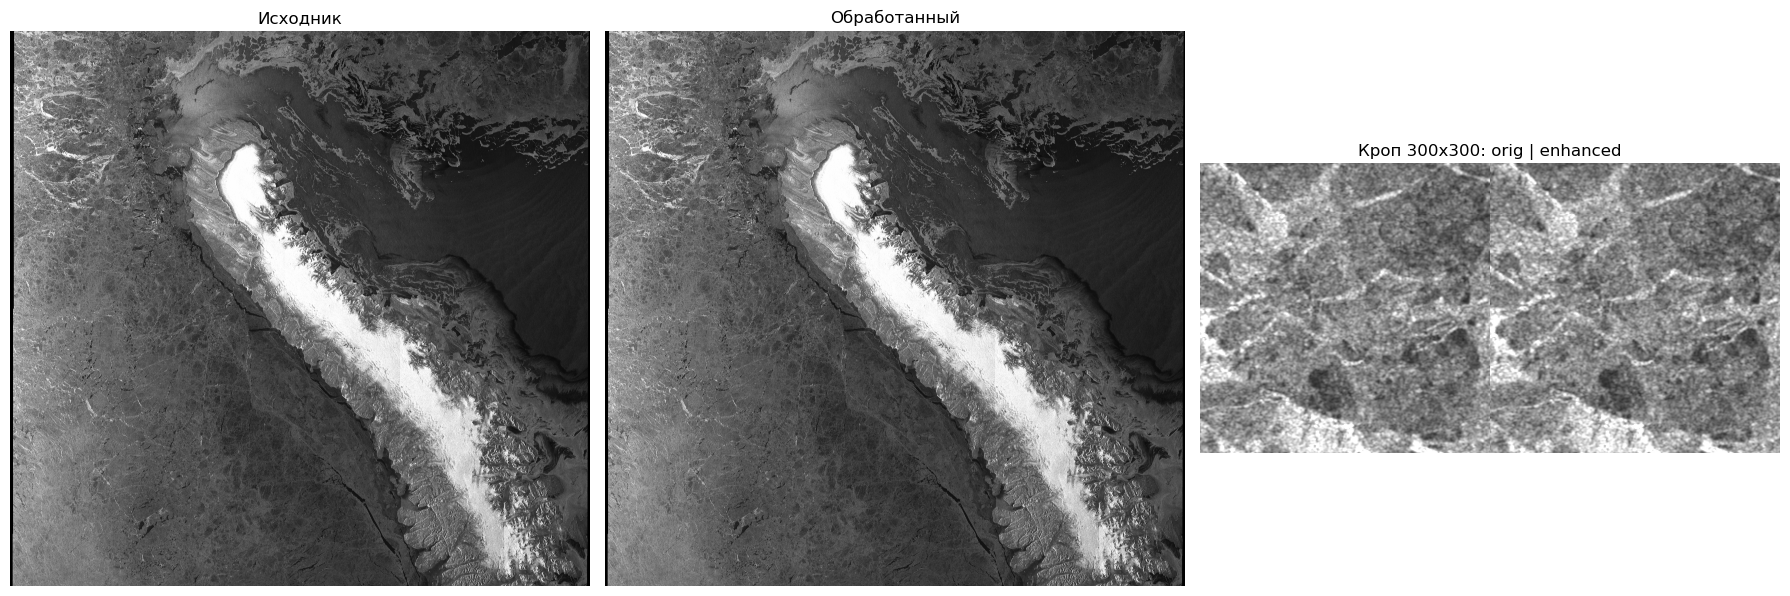

TypeError: unsupported format string passed to NoneType.__format__

In [7]:
import numpy as np
from src.storage import HDFSClient, HDFSConfig
from src.utils import load_config
import io

cfg = load_config('/app/config/settings.yaml')
hdfs = HDFSClient(HDFSConfig(
    root=cfg['storage']['hdfs_root'],
    input_dir=cfg['storage']['input_dir'],
    output_dir=cfg['storage']['output_dir'],
    metadata_dir=cfg['storage']['metadata_dir'],
))

enhanced_bytes = hdfs.get_bytes(result['enhanced_path'])
enhanced = np.asarray(Image.open(io.BytesIO(enhanced_bytes)))
original = np.asarray(Image.open(sample_path).convert('RGB'))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(original);  axes[0].set_title('Исходник');    axes[0].axis('off')
axes[1].imshow(enhanced);  axes[1].set_title('Обработанный'); axes[1].axis('off')
# Кроп для детального сравнения
crop = slice(400, 700)
axes[2].imshow(np.hstack([original[crop, crop], enhanced[crop, crop]]))
axes[2].set_title('Кроп 300x300: orig | enhanced'); axes[2].axis('off')
plt.tight_layout(); plt.show()

print(f"PSNR = {result['metrics']['psnr_db']:.2f} dB")
print(f"SSIM = {result['metrics']['ssim']:.4f}")
print(f"Время инференса:   {result['inference_time_sec']} сек")
print(f"Полное время:      {result['total_time_sec']} сек")
print(f"Обработано тайлов: {result['num_tiles']}")